In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
x=np.array([1,2,3,4,5]).reshape(-1,1)

In [3]:
x

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [4]:
#output:marks
y=np.array([40,50,50,60,70])
y

array([40, 50, 50, 60, 70])

In [5]:
#create and train model
model=LinearRegression()
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7.]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,33
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[3.16]


In [6]:
#displaying regression parameters
print("Intercept: ",model.intercept_)
print("Slope: ",model.coef_[0])

Intercept:  33.0
Slope:  7.0


In [7]:
#predict marks for 6 hours
new_data=np.array([[6]])
predicted_mark=model.predict(new_data)

In [8]:
print("predicted_mark: ",predicted_mark[0])

predicted_mark:  75.0


In [9]:
#predictions for the original obeservations
y_pred=model.predict(x)
y_pred

array([40., 47., 54., 61., 68.])

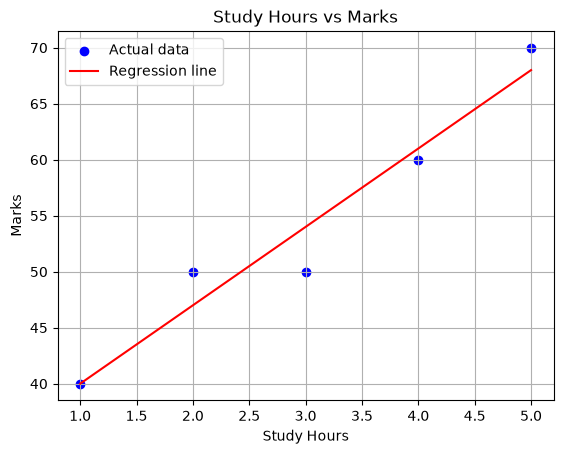

In [10]:
#plot data and regression line
plt.scatter(x,y, color="blue", label="Actual data")
plt.plot(x,y_pred, color="red",label="Regression line")

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")
plt.legend()
plt.grid(True)
plt.show()

Evaluating the python model

in a linear regresser we use performance metric (MAE,MSE,RMSE,R^2)

In [11]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [12]:
mae=mean_absolute_error(y,y_pred)
mse=mean_squared_error(y,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y,y_pred)

In [13]:
print("MAE : ",mae)
print("MSE : ",mse)
print("RMSE : ",rmse)
print("R-Squared : ",r2)

MAE :  2.0
MSE :  6.0
RMSE :  2.449489742783178
R-Squared :  0.9423076923076923


Train - test split example

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

In [15]:
data={
    "Study_Hours":[1,2,3,4,5,6,7,8,9,10],
    "Marks":[32,38,43,50,54,61,68,73,81,88]
}

In [16]:
df=pd.DataFrame(data)
df

,Study_Hours,Marks
0,1,32
1,2,38
2,3,43
3,4,50
4,5,54
5,6,61
6,7,68
7,8,73
8,9,81
9,10,88


In [17]:
X=df[["Study_Hours"]]
y=df["Marks"]

In [18]:
X

,Study_Hours
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [19]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[6.16]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Study_Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,24.72
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [21]:
y_pred=model.predict(X_test)

In [22]:
print("Intercept : ",model.intercept_)
print("Slope : ",model.coef_[0])

Intercept :  24.724137931034484
Slope :  6.163793103448276


In [23]:
print("Actual values: ",y_test.values)
print("predicted values: ",y_pred)

Actual values:  [81 38]
predicted values:  [80.19827586 37.05172414]


In [24]:
print("MAE : ",mean_absolute_error(y_test,y_pred))
print("MSE : ",mean_squared_error(y_test,y_pred))
print("RMSE : ",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R-Squared : ",r2_score(y_test,y_pred))

MAE :  0.875
MSE :  0.7709943519619504
RMSE :  0.8780628405541089
R-Squared :  0.9983320836085193


Multiple Linear Regression in Python

In [25]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [26]:
data={
    "Study_Hours":[2,3,4,5,6,7,8,9],
    "Attendence":[60,65,70,75,80,85,90,95],
    "Assignment_Score":[50,55,58,65,70,74,80,88],
    "Final_Marks":[42,48,54,61,67,73,81,89]
    }

In [27]:
df=pd.DataFrame(data)

X=df[["Study_Hours","Attendence","Assignment_Score"]]
y=df["Final_Marks"]

In [28]:
model=LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.13,0.66,0.61]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Study_Hours','Attendence','Assignment_Score']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-28.32
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [29]:
print("Intercept : ",model.intercept_)


Intercept :  -28.31652806652808


In [30]:
coefficient_table=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient": model.coef_
})

In [31]:
print(coefficient_table)

            Feature  Coefficient
0       Study_Hours     0.131410
1        Attendence     0.657051
2  Assignment_Score     0.608108


In [32]:
new_student=pd.DataFrame({
    "Study_Hours":[6],
    "Attendence":[82],
    "Assignment_Score":[72]
})

In [33]:
prediction=model.predict(new_student)
print("Predicted Final Mark: ",prediction[0])

Predicted Final Mark:  70.13392238392238


USING DATASET

In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [54]:
df=pd.read_csv(r"D:\BDA_0024\AML_LAB\project_lab_5\data\student_performance.csv")

In [55]:
df

,Study_Hours,Attendence,Assignment_Score,Final_Marks
0,2,60,50,42
1,3,65,55,48
2,4,70,58,54
3,5,75,65,61
4,6,80,70,67
5,7,85,74,73
6,8,90,80,81
7,9,95,88,89


In [56]:
X=df[["Study_Hours","Attendence","Assignment_Score"]]
y=df["Final_Marks"]

In [57]:
# Check missing values
df.isnull().sum()

Study_Hours         0
Attendence          0
Assignment_Score    0
Final_Marks         0
dtype: int64

In [58]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [59]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [60]:
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.15,0.73,0.53]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Study_Hours','Attendence','Assignment_Score']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-29.24
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [64]:
y_pred=model.predict(X_test)

In [65]:
print("Intercept : ",model.intercept_)


Intercept :  -29.244102564102562


In [66]:
coefficient_table=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient": model.coef_
})

In [67]:
print(coefficient_table)

            Feature  Coefficient
0       Study_Hours     0.146923
1        Attendence     0.734615
2  Assignment_Score     0.533333


In [68]:
print("Actual values: ",y_test.values)
print("predicted values: ",y_pred)

Actual values:  [48 73]
predicted values:  [48.28       73.69333333]


In [74]:
new_student=pd.DataFrame({
    "Study_Hours":[7],
    "Attendence":[85],
    "Assignment_Score":[75]
})

In [75]:
prediction=model.predict(new_student)
print("Predicted Final Mark: ",prediction[0])

Predicted Final Mark:  74.22666666666667


In [76]:
print("MAE : ",mean_absolute_error(y_test,y_pred))
print("MSE : ",mean_squared_error(y_test,y_pred))
print("RMSE : ",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R-Squared : ",r2_score(y_test,y_pred))

MAE :  0.4866666666666717
MSE :  0.27955555555556205
RMSE :  0.5287301349039621
R-Squared :  0.9982108444444444


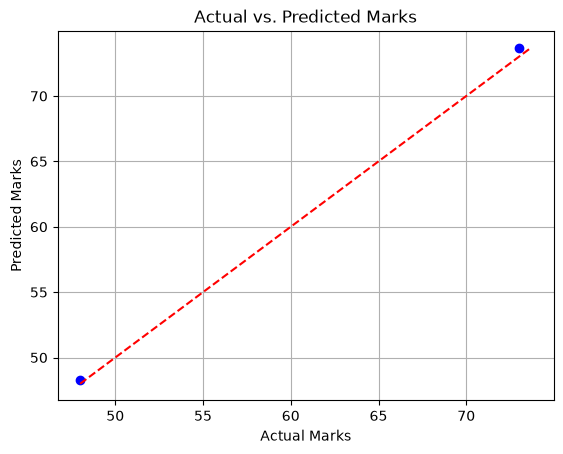

In [77]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color="blue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
[minimum, maximum],
[minimum, maximum],
color="red",
linestyle="--"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs. Predicted Marks")
plt.grid(True)
plt.show()

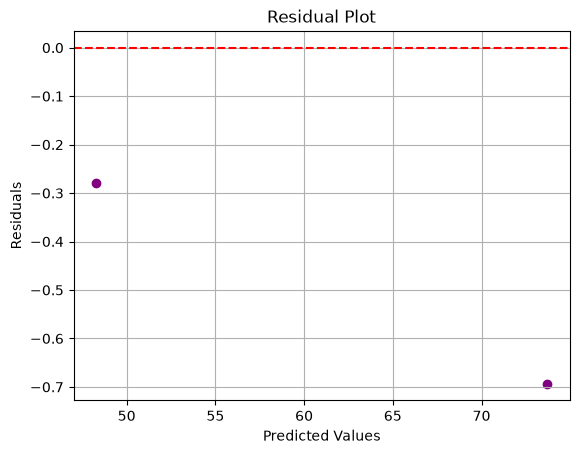

In [71]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, color="purple")
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()